# Td-Tp 3 : Propagation avant et rétropropagation

Bienvenue dans votre premier exercice de programmation de réseaux neuronaux ! Vous allez construire un réseau de rétroaction simple pour implémenter un classificateur de régression logistique, identifiant finalement les images de chats. L'exécution des tâches de programmation ci-dessous vous guidera tout au long du processus de création de réseau et perfectionnera également votre intuition pour l'apprentissage en profondeur.

**Quelques exigences supplémentaires :**
1. N'utilisez pas de boucles (for/while) dans votre code à moins que les instructions ne vous le demandent explicitement.
2. Utilisez `np.dot(X,Y)` pour calculer le produit scalaire.

**Objectif d'apprentissage :**
Réaliser l'algorithme, comprenant les étapes suivantes:
1. Initialiser les paramètres
2. Calculer la fonction objectif (fonction de coût) et son gradient
3. Utiliser des algorithmes d'optimisation (descente de gradient)
4. Regroupez les trois fonctions ci-dessus en une seule fonction de modèle principale dans le bon ordre.

## Table des matières
- [1 - Packages](#1)
- [2 - Aperçu de l'ensemble des problèmes](#2)
     - [Exercice 1](#ex-1)
     - [Exercice 2](#ex-2)
- [3 - Architecture générale de l'algorithme d'apprentissage](#3)
- [4 - Construire les parties de l'algorithme](#4)
     - [4.1 - Fonctions d'activation](#4-1)
         - [Exercice 3 - sigmoïde](#ex-3)
     - [4.2 - Initialisation des paramètres](#4-2)
         - [Exercice 4 - initialize_with_zeros](#ex-4)
     - [4.3 - Propagation avant et rétropropagation](#4-3)
         - [Exercice 5 - propagate](#ex-5)
     - [4.4 - Optimisation](#4-4)
         - [Exercice 6 - optimize](#ex-6)
         - [Exercice 7 - predict](#ex-7)
- [5 - Fusionner toutes les fonctions dans un modèle](#5)
     - [Exercice 8 - model](#ex-8)
- [6 - Analyse plus approfondie (facultatif)](#6)
- [7 - Testez avec votre propre image (facultatif)](#7)

<a name='1'></a>
## 1 - Packages ##

Commençons par exécuter la cellule ci-dessous pour importer tous les packages dont vous aurez besoin lors de cette mission.
- [numpy](https://numpy.org/doc/1.20/) est le package fondamental pour le calcul scientifique avec Python.
- [h5py](http://www.h5py.org) est un package courant permettant d'interagir avec un ensemble de données stocké dans un fichier H5.
- [matplotlib](http://matplotlib.org) est une bibliothèque pour tracer des graphiques en Python.
- [PIL](https://pillow.readthedocs.io/en/stable/) et [scipy](https://www.scipy.org/) sont utilisés ici pour tester votre modèle avec votre propre image à la fin .

In [2]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import h5py
import scipy
from PIL import Image
from scipy import ndimage
from public_tests import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [3]:
## Cette fonction est utilisée pour lire les fichiers H5. 
## Aucune modification n'est requise.
def load_dataset():
    train_dataset = h5py.File('datasets/train_catvnoncat.h5', "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_dataset = h5py.File('datasets/test_catvnoncat.h5', "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

<a name='2'></a>
## 2 - Aperçu de l'ensemble des problèmes

**Énoncé du problème** : vous recevez un ensemble de données ("data.h5") contenant :
- un ensemble d'entraînement d'images m_train étiquetées comme chat (y=1) ou non-chat (y=0)
- un ensemble de tests d'images m_test étiquetées comme chat ou non-chat
- chaque image est de forme (num_px, num_px, 3) où 3 est pour les 3 canaux (RVB). Ainsi, chaque image est carrée (hauteur = num_px) et (largeur = num_px).

Vous construirez un algorithme simple de reconnaissance d’images capable de classer correctement les images comme chat ou non-chat.

Familiarisons-nous davantage avec l'ensemble de données. Chargez les données en exécutant le code suivant.

In [4]:
# Chargement des données (chat/non-chat)
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

Nous avons ajouté '_orig' à la fin des ensembles de données d'images ('train' et 'test') car nous allons les prétraiter. Après prétraitement, nous nous retrouverons avec 'train_set_x' et 'test_set_x' (les étiquettes 'train_set_y' et 'test_set_y' n'ont besoin d'aucun prétraitement).

Chaque ligne de vos 'train_set_x_orig' et 'test_set_x_orig' est un tableau (*array*) représentant une image. Vous pouvez visualiser un exemple en exécutant le code suivant. N'hésitez pas également à modifier la valeur `index` et à réexécuter pour voir d'autres images.

y = [1], c'est une photo de chat


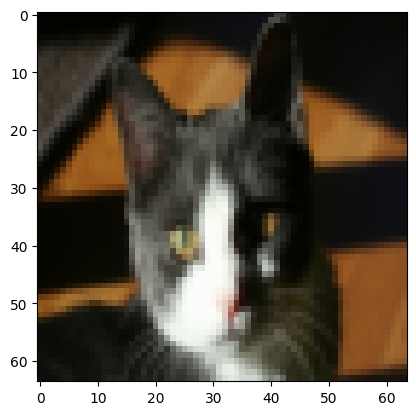

In [5]:
# Exemple d'une photo
index = 19
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", c'est une photo de " + classes[np.squeeze(train_set_y[:, index])].decode("utf-8"))

**Remarque :**

**De nombreux bugs logiciels dans l'apprentissage profond proviennent de dimensions matricielles/vecteurs qui ne correspondent pas. Si vous pouvez garder les dimensions de votre matrice/vecteur droites, vous contribuerez grandement à éliminer de nombreux bugs.**

<a name='ex-1'></a>
### Exercice 1
Trouvez les valeurs pour :
- n_train (nombre d'exemples d'entraînement)
- n_test (nombre d'exemples de test)
- num_px (= hauteur = largeur d'une image d'entraînement)
N'oubliez pas que `train_set_x_orig` est un tableau numpy de formes (n_train, num_px, num_px, 3). Par exemple, vous pouvez accéder à `n_train` en écrivant `train_set_x_orig.shape[0]`.

In [6]:
# n_train = 
# n_test = 
# num_px = 
######### 3 lignes ##########
n_train = train_set_x_orig.shape[0]
n_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]  
#############################

print ("Nombre d'exemples de entraînement : n_train = " + str(n_train))
print ("Nombre d'exemples de test : n_test = " + str(n_test))
print ("Hauteur/Largeur de chaque image : num_px = " + str(num_px))
print ("Chaque image est de taille : (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_set_x taille : " + str(train_set_x_orig.shape))
print ("train_set_y taille : " + str(train_set_y.shape))
print ("test_set_x taille : " + str(test_set_x_orig.shape))
print ("test_set_y taille : " + str(test_set_y.shape))

Nombre d'exemples de entraînement : n_train = 209
Nombre d'exemples de test : n_test = 50
Hauteur/Largeur de chaque image : num_px = 64
Chaque image est de taille : (64, 64, 3)
train_set_x taille : (209, 64, 64, 3)
train_set_y taille : (1, 209)
test_set_x taille : (50, 64, 64, 3)
test_set_y taille : (1, 50)


**Résultat attendu pour n_train, n_test and num_px**: 
<table style="width:15%">
  <tr>
    <td> n_train </td>
    <td> 209 </td> 
  </tr>
  
  <tr>
    <td> n_test </td>
    <td> 50 </td> 
  </tr>
  
  <tr>
    <td> num_px </td>
    <td> 64 </td> 
  </tr>
  
</table>

Pour plus de commodité, vous devez maintenant remodeler les images de forme (num_px, num_px, 3) dans un tableau numpy de forme (num_px $\times$ num_px $\times$ 3, 1). Après cela, notre ensemble de données de entraînement (et de test) est un tableau numpy où chaque colonne représente une image aplatie (`flatten`). Il devrait y avoir des colonnes n_train (respectivement n_test).

<a name='ex-2'></a>
### Exercice 2
Remodelez les ensembles de données d'entraînement et de test afin que les images de taille (num_px, num_px, 3) soient aplaties en vecteurs de forme uniques (num_px $\times$ num_px $\times$ 3, 1).

Une astuce lorsque vous souhaitez aplatir une matrice X de forme (a,b,c,d) en une matrice X_flatten de forme (b $\times$ c $\times$ d, a) est d'utiliser :
```python
X_flatten = X.reshape(X.shape[0], -1).T      # X.T est la transposée de X
```

In [7]:
# Remodeler les exemples d'entraînement et de test
# train_set_x_flatten = ...
# test_set_x_flatten = ...
######### 2 lignes ##########
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T 
#############################

# Vérifiez que les 10 premiers pixels de la deuxième image sont au bon endroit
assert np.alltrue(train_set_x_flatten[0:10, 1] == [196, 192, 190, 193, 186, 182, 188, 179, 174, 213]), "Solution mauvaise. Utiliser (X.shape[0], -1).T."
assert np.alltrue(test_set_x_flatten[0:10, 1] == [115, 110, 111, 137, 129, 129, 155, 146, 145, 159]), "Solution mauvaise. Utiliser (X.shape[0], -1).T."

print ("train_set_x_flatten taille : " + str(train_set_x_flatten.shape))
print ("train_set_y taille : " + str(train_set_y.shape))
print ("test_set_x_flatten taille : " + str(test_set_x_flatten.shape))
print ("test_set_y taille : " + str(test_set_y.shape))

train_set_x_flatten taille : (12288, 209)
train_set_y taille : (1, 209)
test_set_x_flatten taille : (12288, 50)
test_set_y taille : (1, 50)


**Résultat attendu**: 

<table style="width:35%">
  <tr>
    <td> NOM </td>
    <td> TAILLE </td> 
  </tr>
  <tr>
    <td> train_set_x_flatten </td>
    <td> (12288, 209)</td> 
  </tr>
  <tr>
    <td> train_set_y </td>
    <td>(1, 209)</td> 
  </tr>
  <tr>
    <td> test_set_x_flatten </td>
    <td>(12288, 50)</td> 
  </tr>
  <tr>
    <td>test_set_y </td>
    <td>(1, 50)</td> 
  </tr>
</table>

Pour représenter des images en couleur, les canaux rouge, vert et bleu (RVB) doivent être spécifiés pour chaque pixel. Ainsi, la valeur du pixel est en réalité un vecteur de trois nombres allant de 0 à 255.

Une étape de prétraitement courante dans l'apprentissage automatique consiste à centrer et à normaliser votre ensemble de données. Cela signifie que vous soustrayez la moyenne de l'ensemble du tableau numpy pour chaque exemple, puis divisez chaque exemple par l'écart type de l'ensemble du tableau numpy. Cependant, pour les ensembles de données d'images, il est plus simple et presque aussi efficace de diviser chaque ligne de l'ensemble de données par 255 (la valeur maximale d'un canal de pixels).

<!-- Lors de l'entraînement de votre modèle, vous allez multiplier les poids et ajouter des biais à certaines entrées initiales afin d'observer les activations neuronales. Ensuite, vous rétropropagez avec les dégradés pour entraîner le modèle. Il est cependant extrêmement important que chaque caractéristique ait une plage similaire afin d'éviter des problèmes de divergence des gradients. !-->

Procédons à la standardisation de notre ensemble de données.

In [8]:
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flatten / 255.

<font color='blue'>
    
**Ce dont vous devez vous souvenir :**
    
Les étapes pour le prétraitement d'un ensemble de données sont :
- Déterminez les dimensions et les formes du problème (n_train, n_test, num_px, ...)
- Reformuler les ensembles de données de telle sorte que chaque exemple soit désormais un vecteur de taille (num_px $\times$ num_px $\times$ 3, 1)
- "Standardiser" les données

<a name='3'></a>
## 3 - Architecture générale de l'algorithme d'apprentissage
Nous commençons maintenant à concevoir un algorithme simple pour distinguer les images de chats des images non-chats.

Ici, nous utiliserons la pensée des réseaux de neurones pour construire une régression logistique. L'image ci-dessous explique **pourquoi la régression logistique est en fait un réseau de neurones.**

<img src="images/LogReg_kiank.png" style="width:700px;height:350px;">

**Expression mathématique de l'algorithme**:

Par exemple $x_i$:
$$z_i = w^T x_i + b$$
$$\hat{y}_i = \sigma(z_i) = sigmoid(z_i)$$ 
$$ \mathcal{L} = l(y_i,\hat{y}_i) =  - y_i  \log(\hat{y}_i) - (1-y_i)  \log(1-\hat{y}_i)$$

Le coût est ensuite calculé en additionnant tous les exemples de formation :
$$ J = \frac{1}{n} \sum_{i=1}^n l(y_i, \hat{y}_i)$$

**Étapes nécessaires**:
Dans cet exercice, vous effectuerez les étapes suivantes :
- Initialiser les paramètres du modèle
- Apprendre les paramètres du modèle en minimisant le coût
- Utiliser les paramètres appris pour faire des prédictions (sur l'ensemble de test)
- Analyser les résultats et conclure

<a name='4'></a>
## 4 - Construire les parties de l'algorithme
Les principales étapes pour construire un réseau de neurones sont :
1. Définir la structure du modèle (comme le nombre d'entités en entrée)
2. Initialiser les paramètres du modèle
3. Boucles :
    - Calculer la perte actuelle (propagation vers l'avant)
    - Calculer le gradient actuel (propagation vers l'arrière)
    - Mettre à jour les paramètres (descente de gradient)

Vous construisez souvent les étapes 1 à 3 séparément et les intégrez dans une fonction que nous appelons `model()`.

<a name='4-1'></a>
### 4.1 - Fonctions d'activation

<a name='ex-3'></a>
### Exercise 3 - sigmoïde
En utilisant votre code de "Python Basics", implémentez `sigmoid()`. Comme vous l'avez vu dans la figure ci-dessus, vous devez calculer $sigmoid(z) = \frac{1}{1 + e^{-z}}$ pour $z = w^T\cdot x + b$ pour faire des prédictions. Utilisez `np.exp()`.

In [9]:
## fonction sigmoïde

def sigmoid(z):
    """
    Calculer la sigmoïde de z

    Paramètres:
    z -- Un tableau scalaire ou numpy de n'importe quelle taille.

    Retour:
    s -- sigmoïde(z)
    """

    # s = ...
    ########## 1 ligne ##########
    s = 1/(1+np.exp(-z))
    #############################
    
    return s

In [10]:
print ("sigmoïde([0, 2]) = " + str(sigmoid(np.array([0,2]))))

sigmoid_test(sigmoid)

sigmoïde([0, 2]) = [0.5        0.88079708]
Tous les tests ont été passés !


In [11]:
x = np.array([0.5, 0, 2.0])
output = sigmoid(x)
print(output)

[0.62245933 0.5        0.88079708]


<a name='4-2'></a>
### 4.2 - Initialisation des paramètres

<a name='ex-4'></a>
### Exercice 4 - initialize_with_zeros
Implémentez l'initialisation des paramètres dans la cellule ci-dessous. Vous devez initialiser w comme vecteur de zéros. Si vous ne savez pas quelle fonction numpy utiliser, recherchez `np.zeros()` dans la documentation de la bibliothèque Numpy.

In [12]:
## initialize_with_zeros

def initialize_with_zeros(dim):
    """
    Cette fonction crée un vecteur de zéros de forme (dim, 1) pour w et initialise b à 0.
    
    Paramètres:
    dim -- taille du vecteur w souhaité (ou nombre de paramètres dans ce cas)
    
    Retour:
    w -- vecteur de forme initialisé (dim, 1)
    b -- scalaire initialisé (correspond au biais) de type float
    """
    
    # w = ...
    # b = ...
    ######### 2 lignes ##########
    w = np.zeros([dim,1])
    b = 0.0
    #############################

    return w, b

In [13]:
dim = 2
w, b = initialize_with_zeros(dim)

assert type(b) == float
print ("w = " + str(w))
print ("b = " + str(b))

initialize_with_zeros_test_1(initialize_with_zeros)
initialize_with_zeros_test_2(initialize_with_zeros)

w = [[0.]
 [0.]]
b = 0.0
Premier test réussi !
Deuxième test réussi !


<a name='4-3'></a>
### 4.3 - Propagation avant et rétropropagation

Maintenant, vos paramètres sont initialisés. Vous pouvez effectuer les étapes de propagation « avant » et « arrière » pour apprendre automatiquement les paramètres.

<a name='ex-5'></a>
### Exercice 5 - propagate
Implémentez une fonction `propagate()` qui calcule la fonction de coût et son gradient.

**Indices**:

Propagation avant :
- Vous obtenez X
- Vous calculez $\hat{Y} = \sigma(w^T X + b) = (\hat{y}_1, \hat{y}_2, ..., \hat{y}_{n-1}, \hat{y}_n)$
- Vous calculez la fonction de coût : $J = -\frac{1}{n}\sum_{i=1}^{n}(y_i\log(\hat{y}_i)+ (1-y_i)\log(1-\hat{y}_i))$

Voici les deux formules que vous utiliserez :
$$ \frac{\partial J}{\partial w} = \frac{1}{n}X(\hat{Y}-Y)^T$$
$$ \frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^n (\hat{y}_i-y_i)$$

In [14]:
## propagate

def propagate(w, b, X, Y):
    """
    Implémenter la fonction de coût et son gradient pour la propagation expliquée ci-dessus

    Paramètres:
    w -- poids, un tableau numpy de taille (num_px * num_px * 3, 1)
    b -- biais, un scalaire
    X -- données de taille (num_px * num_px * 3, nombre d'exemples)
    Y -- vecteur "étiquette" (contenant 0 si non-chat, 1 si chat) de taille (1, nombre d'exemples)

    Retour:
    grads -- dictionnaire contenant les gradients des poids et des biais
            (dw -- gradient de la perte par rapport à w, donc même forme que w)
            (db -- gradient de la perte par rapport à b, donc même forme que b)
    coût - coût de log-vraisemblance négatif (负对数似然函数) pour la régression logistique
    
    Conseils:
    - Écrivez votre code étape par étape pour la propagation. np.log(), np.dot()
    """
    
    n = X.shape[1]
    
    ## PROPAGATION AVANT (DE X AU COÛT)
    ## activation du calcul
    # hat_Y = ...
    ## calculez le coût en utilisant np.dot pour effectuer la multiplication.
    ## n'utilisez pas de Boucles pour la somme.
    # cost = ...                                
    ######### 2 lignes ##########
    hat_Y = sigmoid(np.dot(w.T,X)+b)
    cost = -1/n * (np.dot(Y,np.log(hat_Y).T) + np.dot((1-Y),np.log(1 - hat_Y).T))
    #############################

    ## PROPAGATION ARRIÈRE (POUR TROUVER LE GRAD)
    # dw = ...
    # db = ...
    ######### 2 lignes ##########
    dw = 1/n * np.dot(X,(hat_Y-Y).T)
    db = 1/n * np.sum(hat_Y-Y)
    #############################
    
    cost = np.squeeze(np.array(cost))
    
    grads = {"dw": dw,
             "db": db}
    
    return grads, cost

In [15]:
w =  np.array([[1.], [2]])
b = 1.5
X = np.array([[1., -2., -1.], [3., 0.5, -3.2]])
Y = np.array([[1, 1, 0]])
grads, cost = propagate(w, b, X, Y)

assert type(grads["dw"]) == np.ndarray
assert grads["dw"].shape == (2, 1)
assert type(grads["db"]) == np.float64


print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print ("coût = " + str(cost))

propagate_test(propagate)

dw = [[ 0.25071532]
 [-0.06604096]]
db = -0.1250040450043965
coût = 0.15900537707692405
Tous les tests ont été passés !


**Résultat attendu**

```
dw = [[ 0.25071532]
 [-0.06604096]]
db = -0.1250040450043965
cost = 0.15900537707692405
```

<a name='4-4'></a>
### 4.4 - Optimisation
- Vous avez initialisé vos paramètres.
- Vous êtes également capable de calculer une fonction de coût et son gradient.
- Maintenant, vous devez mettre à jour les paramètres en utilisant la descente de gradient.

<a name='ex-6'></a>
### Exercice 6 - optimize
Notez la fonction d'optimisation. Le but est d'apprendre $w$ et $b$ en minimisant la fonction de coût $J$. Pour un paramètre $\theta$, la règle de mise à jour est $\theta = \theta + \Delta \theta = \theta - \eta \, d\theta$, où $\eta$ est le taux d'apprentissage.

In [16]:
## optimize

def optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False):
    """
    Cette fonction optimise les paramètres w et b en exécutant un algorithme de descente de gradient.

    Paramètres :
    w -- poids, un tableau numpy de taille (num_px * num_px * 3, 1)
    b -- biais, un scalaire
    X -- données de forme (num_px * num_px * 3, nombre d'exemples)
    Y -- vrai vecteur "étiquette" (contenant 0 si non-chat, 1 si chat), de forme (1, \nombre d'exemples)
    num_iterations -- nombre d'itérations de la boucle d'optimisation
    learning_rate -- taux d'apprentissage de la règle de mise à jour de la descente de gradient
    print_cost -- True pour imprimer la perte toutes les 100 étapes

    Retour :
    params -- dictionnaire contenant les poids w et le biais b
    grads -- dictionnaire contenant les gradients des poids et des biais par rapport à la fonction de coût
    costs -- liste de tous les coûts calculés lors de l'optimisation, cela sera utilisé pour tracer la courbe d'apprentissage

    Conseils :
    Vous devez essentiellement écrire deux étapes et les parcourir :
        1) Calculez le coût et le gradient pour les paramètres actuels. Utilisez la fonction de propagation `propager()`.
        2) Mettez à jour les paramètres à l'aide de la règle de descente de gradient pour w et b.
    """
    
    w = copy.deepcopy(w)
    b = copy.deepcopy(b)
    
    costs = []
    
    for i in range(num_iterations):
        ## Calcul du coût et du gradient 
        # grads, cost = ...
        ########## 1 ligne ##########
        grads, cost = propagate(w, b, X, Y)
        #############################
        
        ## Récupérer les dérivés de grads
        dw = grads["dw"]
        db = grads["db"]
        
        ## mise à jour
        # w = ...
        # b = ...
        ######### 2 lignes ##########
        w += -learning_rate * dw
        b += -learning_rate * db
        #############################
        
        ## Enregistrer les coûts
        if i % 100 == 0:
            costs.append(cost)
        
            ## Imprimer le coût toutes les 100 itérations d'entraînement
            if print_cost:
                print ("Coût après itération %i: %f" %(i, cost))
    
    params = {"w": w,
              "b": b}
    
    grads = {"dw": dw,
             "db": db}
    
    return params, grads, costs

In [17]:
params, grads, costs = optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print("Coûts = " + str(costs))

optimize_test(optimize)

w = [[0.80956046]
 [2.0508202 ]]
b = 1.5948713189708588
dw = [[ 0.17860505]
 [-0.04840656]]
db = -0.08888460336847771
Coûts = [array(0.15900538)]
Tous les tests ont été passés !


<a name='ex-7'></a>
### Exercice 7 - predict
La fonction précédente a produit les w et b appris. Nous pouvons utiliser w et b pour prédire les étiquettes d'un ensemble de données X. Implémentez la fonction `predict()`. Le calcul des prédictions se fait en deux étapes :

1. Calculez $\hat{Y} = \sigma(w^T X + b)$

2. Convertit les entrées de $\hat{y}$ en 0 (si activation <= 0,5) ou 1 (si activation > 0,5), stocke les prédictions dans un vecteur `Y_prediction`. Si vous le souhaitez, vous pouvez utiliser une instruction `if`/`else` dans une boucle `for` (bien qu'il existe également un moyen de vectoriser cela).

In [18]:
## predict

def predict(w, b, X):
    '''
    Prédire si l'étiquette est 0 ou 1 à l'aide des paramètres de régression logistique appris (w, b)
    
    Paramètres:
    w -- poids, un tableau numpy de taille (num_px * num_px * 3, 1)
    b -- biais, un scalaire
    X -- données de taille (num_px * num_px * 3, nombre d'exemples)
    
    Retour:
    Y_prediction -- un tableau numpy (vecteur) contenant toutes les prédictions (0/1) pour les exemples dans X
    '''
    
    n = X.shape[1]
    Y_prediction = np.zeros((1, n))
    w = w.reshape(X.shape[0], 1)
    
    ## Calculer le vecteur "hat_Y" prédisant les probabilités qu'un chat soit présent dans l'image
    # hat_Y = ...
    ########## 1 ligne ##########
    hat_Y = sigmoid(np.dot(w.T,X)+b)
    #############################
    
    for i in range(hat_Y.shape[1]):
        ## Convertir les probabilités hat_Y[0,i] en prédictions réelles p[0,i]
        # if hat_Y[0, i] > ____ :
        #     Y_prediction[0,i] = 
        # else:
        #     Y_prediction[0,i] = 
        ######### 4 lignes ##########
        if hat_Y[0, i] > 0.5 :
            Y_prediction[0,i] = 1
        else:
            Y_prediction[0,i] = 0
        #############################
    
    return Y_prediction

In [19]:
w = np.array([[0.1124579], [0.23106775]])
b = -0.3
X = np.array([[1., -1.1, -3.2],[1.2, 2., 0.1]])
print ("prédictions = " + str(predict(w, b, X)))

predict_test(predict)

prédictions = [[1. 1. 0.]]
Tous les tests ont été passés !


<font color='blue'>
    
**Ce qu'il faut retenir :**
    
Vous avez implémenté plusieurs fonctions qui :
- Initialize (w,b)
- Optimiser la perte de manière itérative pour apprendre les paramètres (w,b):
    - Calcul du coût et de son gradient
    - Mise à jour des paramètres par descente de gradient
- Utilisez l'apprentissage (w,b) pour prédire les étiquettes pour un ensemble d'exemples donné

<a name='5'></a>
## 5 - Fusionner toutes les fonctions dans un modèle

Vous allez voir comment le modèle global est structuré en rassemblant tous les éléments constitutifs (fonctions implémentées dans les parties précédentes), dans le bon ordre.

<a name='ex-8'></a>
### Exercice 8 - model
Implémentez la fonction de modèle. Utilisez la notation suivante :
- Y_prediction_test pour vos prédictions sur l'ensemble de test
- Y_prediction_train pour vos prédictions sur l‘ensemble d'entraînement
- params, grades, costs pour les sorties d'`optimize()`

In [20]:
## model

def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.5, print_cost=False):
    """
    Construit le modèle de régression logistique en appelant la fonction que vous avez implémentée précédemment
    
    Paramètres:
    X_train -- ensemble d'entraînement représenté par un tableau numpy de formes (num_px * num_px * 3, n_train)
    Y_train - étiquettes d'entraînement représentées par un tableau numpy (vecteur) de forme (1, n_train)
    X_test -- ensemble de tests représenté par un tableau numpy de forme (num_px * num_px * 3, n_test)
    Y_test - étiquettes de test représentées par un tableau numpy (vecteur) de forme (1, n_test)
    num_iterations -- hyperparamètre représentant le nombre d'itérations pour optimiser les paramètres
    learning_rate -- hyperparamètre représentant le taux d'apprentissage utilisé dans la règle de mise à jour d'optimise()
    print_cost -- Définir True pour imprimer le coût toutes les 100 itérations
    
    Retour:
    d -- dictionnaire contenant des informations sur le modèle.
    """  
    ## initialiser les paramètres avec des zéros
    ## utilisez la fonction `shape` pour obtenir la première dimension de X_train
    # w, b = ...
    ########## 1 ligne ##########
    w, b = initialize_with_zeros(X_train.shape[0])
    #############################
    
    ## Descente de gradient
    # params, grads, costs = ...
    ########## 1 ligne ##########
    params, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)
    #############################
    
    ## Récupérer les paramètres w et b du dictionnaire `params`
    # w = ...
    # b = ...
    ######### 2 lignes ##########
    w = params["w"]
    b = params["b"]
    #############################
        
    ## Prédire les exemples d'ensembles de test/d'entraînement
    # Y_prediction_test = ...
    # Y_prediction_train = ...
    ######### 2 lignes ##########
    Y_prediction_test = predict(w, b, X_test)
    Y_prediction_train = predict(w, b, X_train)
    #############################

    ## Imprimer les erreurs d'entraînement/de test
    if print_cost:
        print("précision des entraînements : {} %".format(100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100))
        print("précision des tests : {} %".format(100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100))

    
    d = {"costs": costs,
         "Y_prediction_test": Y_prediction_test, 
         "Y_prediction_train" : Y_prediction_train, 
         "w" : w, 
         "b" : b,
         "learning_rate" : learning_rate,
         "num_iterations": num_iterations}
    
    return d

In [21]:
from public_tests import *

model_test(model)

Tous les tests ont été passés !


**Si vous réussissez tous les tests, exécutez la cellule suivante pour entraîner votre modèle.**

In [22]:
logistic_regression_model = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=2000, learning_rate=0.005, print_cost=True)

Coût après itération 0: 0.693147
Coût après itération 100: 0.584508
Coût après itération 200: 0.466949
Coût après itération 300: 0.376007
Coût après itération 400: 0.331463
Coût après itération 500: 0.303273
Coût après itération 600: 0.279880
Coût après itération 700: 0.260042
Coût après itération 800: 0.242941
Coût après itération 900: 0.228004
Coût après itération 1000: 0.214820
Coût après itération 1100: 0.203078
Coût après itération 1200: 0.192544
Coût après itération 1300: 0.183033
Coût après itération 1400: 0.174399
Coût après itération 1500: 0.166521
Coût après itération 1600: 0.159305
Coût après itération 1700: 0.152667
Coût après itération 1800: 0.146542
Coût après itération 1900: 0.140872
précision des entraînements : 99.04306220095694 %
précision des tests : 70.0 %


**Commentaire** : La précision de l'entraînement est proche de 100 %. C'est un bon signe : votre modèle fonctionne et a une capacité suffisamment élevée pour s'adapter aux données d'entraînement. La précision des données de test est de 70 %. Ce n'est en fait pas mal pour ce modèle simple, compte tenu du petit ensemble de données que nous avons utilisé et du fait que la régression logistique est un classificateur linéaire.

De plus, vous remarquerez que le modèle surajuste considérablement les données d'entraînement. En effet, nous n'utilisons pas de régularisation. Si vous êtes intéressé, vous pouvez essayer d'ajouter un terme de régularisation à la fonction de coût.

Maintenant, en utilisant le code ci-dessous (et en modifiant la variable `index`), vous pouvez voir les prédictions pour les images de l'ensemble de test.

y = 1, tu as prédit que c'est un "chat".


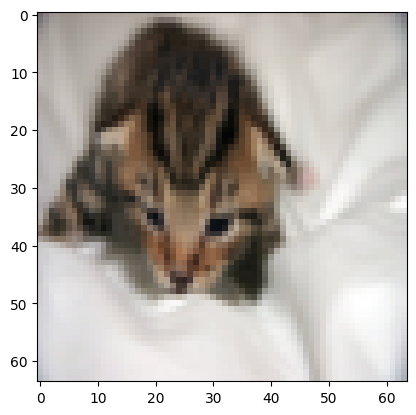

In [23]:
## Exemple de photo mal classée.
index = 1
plt.imshow(test_set_x[:, index].reshape((num_px, num_px, 3)))
print ("y = " + str(test_set_y[0,index]) + ", tu as prédit que c'est un \"" + classes[int(logistic_regression_model['Y_prediction_test'][0,index])].decode("utf-8") +  "\".")

Traçons également la fonction de coût et les gradients.

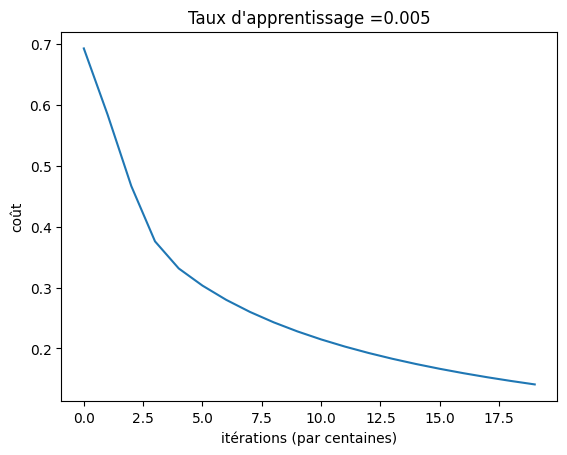

In [24]:
## Courbe d'apprentissage - coûts
costs = np.squeeze(logistic_regression_model['costs'])
plt.plot(costs)
plt.ylabel('coût')
plt.xlabel('itérations (par centaines)')
plt.title("Taux d'apprentissage =" + str(logistic_regression_model["learning_rate"]))
plt.show()

**Interprétation**:
Vous pouvez voir le coût diminuer. Cela montre que les paramètres sont en cours d’apprentissage. Cependant, vous voyez que vous pourriez entraîner encore plus le modèle sur l’ensemble d’entraînement. Essayez d'augmenter le nombre d'itérations dans la cellule ci-dessus et réexécutez les cellules. Vous constaterez peut-être que la précision de l’ensemble d’entraînement augmente, mais que la précision de l’ensemble de test diminue. C’est ce qu’on appelle le surapprentissage.

========================================================================================
========================================================================================
<a name='6'></a>
## 6 - Analyse plus approfondie (facultatif)

Nous disposons maintenant d'un modèle de classification d'images terminé. Analysons-le plus en détail et examinons les choix possibles pour le taux d'apprentissage $\eta$.

### Choix du taux d'apprentissage ###

**Remarque**:
Pour que la descente de gradient fonctionne, vous devez choisir judicieusement le taux d'apprentissage $\eta$, qui détermine la rapidité avec laquelle nous mettons à jour les paramètres. Si le taux d'apprentissage est trop élevé, nous risquons de "dépasser" la valeur optimale. S'il est trop petit, nous aurons besoin de trop d'itérations pour converger vers les meilleures valeurs. C'est pourquoi il est crucial d'utiliser un taux d'apprentissage bien ajusté.

Comparons la courbe d'apprentissage de notre modèle avec plusieurs choix de taux d'apprentissage. Exécutez la cellule ci-dessous. Cela devrait prendre environ 1 minute. N'hésitez pas également à essayer différentes valeurs des trois que nous avons initialisées dans la variable `learning_rates` et voyez ce qui se passe.

Entraîner un modèle avec un taux d'apprentissage : 0.01

-------------------------------------------------------

Entraîner un modèle avec un taux d'apprentissage : 0.001

-------------------------------------------------------

Entraîner un modèle avec un taux d'apprentissage : 0.0001

-------------------------------------------------------



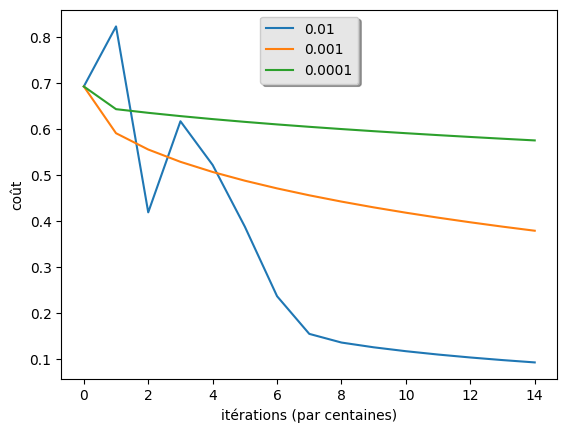

In [25]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}

for lr in learning_rates:
    print ("Entraîner un modèle avec un taux d'apprentissage : " + str(lr))
    models[str(lr)] = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=1500, learning_rate=lr, print_cost=False)
    print ('\n' + "-------------------------------------------------------" + '\n')

for lr in learning_rates:
    plt.plot(np.squeeze(models[str(lr)]["costs"]), label=str(models[str(lr)]["learning_rate"]))

plt.ylabel('coût')
plt.xlabel('itérations (par centaines)')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()

**Intérpretation**: 
- Différents taux d'apprentissage donnent différents coûts et donc différents résultats de prédiction.
- Si le taux d'apprentissage est trop élevé (0,01), le coût peut osciller de haut en bas, voire diverger. Cependant, dans cet exemple, l'utilisation de 0,01 finit toujours par donner une bonne valeur pour le coût.
- Un coût plus bas ne signifie pas forcément un meilleur modèle. Il est important de vérifier s'il y a éventuellement un surajustement. Cela se produit lorsque la précision de l'entraînement est nettement supérieure à celle du test.
- En deep learning, il est généralement recommandé de :
     - Choisir le taux d'apprentissage qui minimise le mieux la fonction de coût.
     - Si votre modèle est surajusté, utiliser d'autres techniques pour réduire le surajustement (nous en parlerons dans des vidéos ultérieures).

<a name='7'></a>
## 7 - Testez avec votre propre image (facultatif)

À ce stade, la construction et les tests de l'algorithme sont terminés. Vous pouvez utiliser vos propres images et afficher la sortie du modèle. Voici comment procéder :
1. Ajoutez l'image au dossier "images" de ce répertoire Jupyter Notebook.
2. Changez le nom de l'image dans le code suivant.
3. Exécutez le code et vérifiez si l'algorithme est correct (1 = chat, 0 = pas chat)

y = 1.0, votre algorithme prédit un "chat".


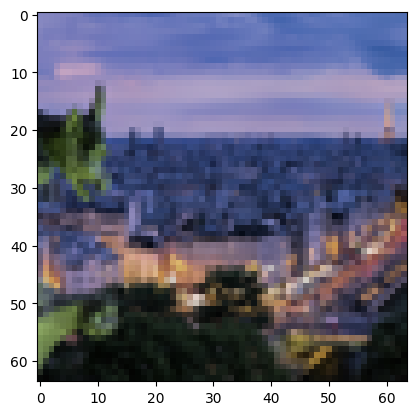

In [30]:
# change this to the name of your image file
my_image = "gargouille.jpg"   

# We preprocess the image to fit your algorithm.
fname = "images/" + my_image
image = np.array(Image.open(fname).resize((num_px, num_px)))
plt.imshow(image)
image = image / 255.
image = image.reshape((1, num_px * num_px * 3)).T
my_predicted_image = predict(logistic_regression_model["w"], logistic_regression_model["b"], image)

print("y = " + str(np.squeeze(my_predicted_image)) + ", votre algorithme prédit un \"" + classes[int(np.squeeze(my_predicted_image)),].decode("utf-8") +  "\".")

<font color='blue'>
    
**Remarque :**
    
1. Le prétraitement des ensembles de données est très important.
2. Vous implémentez chaque fonction séparément : `initialize()`, `propagate()`, `optimiser()`. Ensuite, vous construisez un `model()`.
3. L'ajustement du taux d'apprentissage (qui est un exemple d'« hyperparamètre ») peut avoir un impact important sur l'algorithme.

Bibliography:
- http://www.wildml.com/2015/09/implementing-a-neural-network-from-scratch/
- https://stats.stackexchange.com/questions/211436/why-do-we-normalize-images-by-subtracting-the-datasets-image-mean-and-not-the-c